# Per-FOV inspection table

Computes, for every FOV across all phases, a summary containing

- `phase_id`, `phase_name` (human-readable BO condition label)
- `stim_exposure`, `ramp` (BO parameters for that FOV)
- `optortk_expression_mean` (FOV-mean of per-cell optoRTK reporter)
- `baseline_cnr_mean` (FOV-mean of per-cell baseline CNR)
- `n_cells` (after quality gates)
- `p25`, `p50`, `p75`, `p90` of per-cell `mean_osc_probability`
- `frac_osc_prob_ge_075` — fraction of cells with `mean_osc_probability >= 0.75`

Intended for **manual inspection** — not used to fit any GP.

In [2]:
import os, importlib.util
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# gpax/numpyro compat shim
import numpyro.contrib.module as _ncm


def _haiku_unavailable(*_a, **_k):
    raise NotImplementedError("haiku removed")


if not hasattr(_ncm, "random_haiku_module"):
    _ncm.random_haiku_module = _haiku_unavailable
if not hasattr(_ncm, "haiku_module"):
    _ncm.haiku_module = _haiku_unavailable

RUN_PATH = r"E:\Alex\2026-04-10_bo_erk_oscillation_v4_test"
EXP_DATA_PATH = os.path.join(RUN_PATH, "exp_data.parquet")

N_FRAMES_BASELINE = 10
N_FRAMES_STIM = 60
N_FRAMES_RECOVERY = 20
N_FRAMES = N_FRAMES_BASELINE + N_FRAMES_STIM + N_FRAMES_RECOVERY
FIRST_FRAME_STIM = N_FRAMES_BASELINE
LAST_FRAME_STIM = FIRST_FRAME_STIM + N_FRAMES_STIM

CLASSIFIER_PATH = r"./oscillation_model_60min.joblib"
CLASSIFIER_SCRIPT = r"./apply_oscillation_classifier_v2.py"

In [3]:
import joblib

model_data = joblib.load(CLASSIFIER_PATH)
osc_clf = model_data["clf"]
osc_scaler = model_data["scaler"]
osc_feature_cols = model_data["feature_cols"]
osc_cfg = model_data["config"]
osc_cfg["window_size"] = model_data["window_size"]
osc_cfg["window_step"] = model_data["window_step"]

_spec = importlib.util.spec_from_file_location("osc_clf_mod", CLASSIFIER_SCRIPT)
_mod = importlib.util.module_from_spec(_spec)
_spec.loader.exec_module(_mod)
predict_trace = _mod.predict_trace

df_exp = pd.read_parquet(EXP_DATA_PATH)
cond_map_df = (
    df_exp.groupby(["phase_id", "fov"])
    .agg(
        phase_name=("phase_name", "first"),
        stim_exposure=("stim_exposure", "first"),
        ramp=("ramp", "first"),
    )
    .reset_index()
)
phases = sorted(df_exp["phase_id"].unique())
print(
    f"Loaded {len(df_exp)} rows, {len(phases)} phases, {df_exp['fov'].nunique()} FOVs"
)

Loaded 688761 rows, 9 phases, 162 FOVs


## Preprocess per-cell (single run)

In [4]:
from faro.agents.bo_optimization import BO_Parameter, BO_Objective, BO_Covariate
from faro.agents.bo_oscillation import OscillationBO
from faro.agents.bo_oscillation_single_cell import OscillationBOSingleCell

# Shared config used for all agents
bo_params = [
    BO_Parameter(name="stim_exposure", bounds=(50.0, 500.0), spacing=25.0),
    BO_Parameter(name="ramp", bounds=(0.0, 20.0), spacing=5.0),
]

shared_kwargs = dict(
    n_frames=N_FRAMES,
    first_frame_stim=FIRST_FRAME_STIM,
    last_frame_stim=LAST_FRAME_STIM,
    time_between_timesteps=60,
    imaging_channels=(),
    stim_channel=None,
    optocheck_channel=None,
    osc_clf=osc_clf,
    osc_scaler=osc_scaler,
    osc_feature_cols=osc_feature_cols,
    osc_cfg=osc_cfg,
    osc_predict_fn=predict_trace,
    min_osc_probability=0.0,
    min_consecutive_windows=0,
    min_fft_amplitude=0.0,
    n_baseline_frames=N_FRAMES_BASELINE,
    parameters_to_optimize=bo_params,
    n_iterations=len(phases),
    n_conditions_per_iter=2,
    n_initial_phases=2,
    acquisition_function="ei",
    n_cov_samples=20,
    ei_xi=0.2,
    ei_xi_final=0.01,
    ei_xi_decay_fraction=0.7,
    plot_live=False,
    save_checkpoints=False,
    verbose=False,
)

# Single-cell agent used only for its _preprocess_results (produces per-cell table)
_pre_agent = OscillationBOSingleCell(
    storage_path=os.path.join(RUN_PATH, "replay_quantile_pre"),
    gp_backend="vi_sparse",
    inducing_points_ratio=0.1,
    num_svi_steps=10,
    svi_step_size=5e-3,
    gp_batch_size=2000,
    density_k_neighbours=5,
    bo_covariates=[
        BO_Covariate(name="baseline_cnr"),
        BO_Covariate(name="optortk_expression", log_scale=True),
        BO_Covariate(name="mean_dist_k_nearest"),
    ],
    objective_metric=BO_Objective(name="mean_osc_probability", goal="maximize"),
    **shared_kwargs,
)
os.makedirs(_pre_agent.storage_path, exist_ok=True)
_pre_agent._ensure_results_df()

# FOV-level agent only for its _preprocess_results (FOV metadata)
_fov_pre = OscillationBO(
    storage_path=os.path.join(RUN_PATH, "replay_quantile_fov_pre"),
    bo_covariates=[
        BO_Covariate(name="baseline_cnr"),
        BO_Covariate(name="optortk_expression", log_scale=True),
        BO_Covariate(name="n_cells"),
    ],
    objective_metric=BO_Objective(name="mean_osc_probability", goal="maximize"),
    **shared_kwargs,
)
os.makedirs(_fov_pre.storage_path, exist_ok=True)
_fov_pre._ensure_results_df()

all_cell_rows, all_fov_rows = [], []
for phase_id in phases:
    df_phase_raw = df_exp[df_exp["phase_id"] == phase_id]
    fov_tracks = {
        int(fov): df_phase_raw[df_phase_raw["fov"] == fov].copy()
        for fov in df_phase_raw["fov"].unique()
    }
    cm = cond_map_df[cond_map_df["phase_id"] == phase_id]
    cond_map = {
        int(row["fov"]): dict(
            stim_exposure=float(row["stim_exposure"]), ramp=float(row["ramp"])
        )
        for _, row in cm.iterrows()
    }
    _pre_agent._current_condition_map = cond_map
    _pre_agent._current_phase_id = int(phase_id)
    df_cell = _pre_agent._preprocess_results(fov_tracks)
    if not df_cell.empty:
        all_cell_rows.append(df_cell)

    _fov_pre._current_condition_map = cond_map
    _fov_pre._current_phase_id = int(phase_id)
    df_fov = _fov_pre._preprocess_results(fov_tracks)
    if not df_fov.empty:
        all_fov_rows.append(df_fov)

df_cells = pd.concat(all_cell_rows, ignore_index=True)
df_fovs = pd.concat(all_fov_rows, ignore_index=True)

# Attach phase_name to df_cells and df_fovs
name_map = cond_map_df[["phase_id", "fov", "phase_name"]]
df_cells = df_cells.merge(name_map, on=["phase_id", "fov"], how="left")
df_fovs = df_fovs.merge(name_map, on=["phase_id", "fov"], how="left")

# Drop rows with non-positive optortk_expression (log-scale requires > 0)
df_cells = df_cells[df_cells["optortk_expression"] > 0].reset_index(drop=True)
df_fovs = df_fovs[df_fovs["optortk_expression"] > 0].reset_index(drop=True)

print(f"df_cells: {len(df_cells)} cells across {df_cells['phase_id'].nunique()} phases")
print(f"df_fovs:  {len(df_fovs)} FOVs across {df_fovs['phase_id'].nunique()} phases")
print(
    f"\nPer-FOV cell count stats: mean={df_cells.groupby(['phase_id','fov']).size().mean():.1f}, "
    f"min={df_cells.groupby(['phase_id','fov']).size().min()}, "
    f"max={df_cells.groupby(['phase_id','fov']).size().max()}"
)

  Phase 0: 655 cells (from 18 FOVs), mean mean_osc_probability=0.1092, max=0.9960
  Phase 0: 18 FOVs, mean frac_oscillating=1.0000, max=1.0000
  Phase 1: 285 cells (from 17 FOVs), mean mean_osc_probability=0.1577, max=0.9805
  Phase 1: 12 FOVs, mean frac_oscillating=1.0000, max=1.0000
  Phase 2: 677 cells (from 18 FOVs), mean mean_osc_probability=0.1794, max=0.9969
  Phase 2: 18 FOVs, mean frac_oscillating=0.9986, max=1.0000
  Phase 3: 435 cells (from 18 FOVs), mean mean_osc_probability=0.2145, max=0.9926
  Phase 3: 18 FOVs, mean frac_oscillating=1.0000, max=1.0000
  Phase 4: 409 cells (from 18 FOVs), mean mean_osc_probability=0.2393, max=0.9976
  Phase 4: 17 FOVs, mean frac_oscillating=1.0000, max=1.0000
  Phase 5: 551 cells (from 18 FOVs), mean mean_osc_probability=0.1955, max=0.9980
  Phase 5: 18 FOVs, mean frac_oscillating=1.0000, max=1.0000
  Phase 6: 444 cells (from 18 FOVs), mean mean_osc_probability=0.2820, max=0.9901
  Phase 6: 18 FOVs, mean frac_oscillating=1.0000, max=1.0000

## Build the per-FOV summary table

In [5]:
# Group per-cell data to per-FOV summary
g = df_cells.groupby(["phase_id", "fov"])

fov_summary = g.agg(
    phase_name=("phase_name", "first"),
    stim_exposure=("stim_exposure", "first"),
    ramp=("ramp", "first"),
    n_cells=("particle", "count"),
    optortk_expression_mean=("optortk_expression", "mean"),
    baseline_cnr_mean=("baseline_cnr", "mean"),
    p25=("mean_osc_probability", lambda s: s.quantile(0.25)),
    p50=("mean_osc_probability", "median"),
    p75=("mean_osc_probability", lambda s: s.quantile(0.75)),
    p90=("mean_osc_probability", lambda s: s.quantile(0.90)),
    frac_osc_prob_ge_075=("mean_osc_probability", lambda s: float((s >= 0.75).mean())),
).reset_index()

print(f"{len(fov_summary)} FOVs total")
print("Columns:", list(fov_summary.columns))

161 FOVs total
Columns: ['phase_id', 'fov', 'phase_name', 'stim_exposure', 'ramp', 'n_cells', 'optortk_expression_mean', 'baseline_cnr_mean', 'p25', 'p50', 'p75', 'p90', 'frac_osc_prob_ge_075']


## Display: sorted by `frac_osc_prob_ge_075` (descending)

In [6]:
# Full table view, sorted by frac_osc_prob_ge_075 descending
view = fov_summary.sort_values("frac_osc_prob_ge_075", ascending=False).reset_index(
    drop=True
)
pd.set_option("display.max_rows", 200)
pd.set_option("display.width", 220)
pd.set_option("display.float_format", lambda v: f"{v:.3f}")
print(view.to_string(index=True))

     phase_id  fov        phase_name  stim_exposure   ramp  n_cells  optortk_expression_mean  baseline_cnr_mean   p25   p50   p75   p90  frac_osc_prob_ge_075
0           8  152  BO_iter_8_cond_0        325.000 20.000        3                 1231.731              0.593 0.396 0.784 0.837 0.869                 0.667
1           2   46  BO_iter_2_cond_1        425.000 10.000       24                 1249.071              0.612 0.149 0.421 0.877 0.964                 0.375
2           6  120  BO_iter_6_cond_1        375.000 20.000       28                 1189.290              0.550 0.036 0.266 0.928 0.977                 0.357
3           6  119  BO_iter_6_cond_1        375.000 20.000       10                 1105.025              0.565 0.243 0.484 0.748 0.794                 0.300
4           2   37  BO_iter_2_cond_0        475.000 20.000       22                 1643.984              0.588 0.003 0.064 0.755 0.855                 0.273
5           6  110  BO_iter_6_cond_0        300.000 

## Display: grouped by phase (original order)

In [7]:
view_phase = fov_summary.sort_values(["phase_id", "fov"]).reset_index(drop=True)
print(view_phase.to_string(index=True))

     phase_id  fov        phase_name  stim_exposure   ramp  n_cells  optortk_expression_mean  baseline_cnr_mean   p25   p50   p75   p90  frac_osc_prob_ge_075
0           0    0  BO_iter_0_cond_0         75.000 15.000       82                 1854.374              0.554 0.003 0.018 0.104 0.201                 0.012
1           0    1  BO_iter_0_cond_0         75.000 15.000       44                 2446.926              0.581 0.001 0.005 0.031 0.107                 0.000
2           0    2  BO_iter_0_cond_0         75.000 15.000       17                 1876.518              0.584 0.002 0.011 0.048 0.105                 0.000
3           0    3  BO_iter_0_cond_0         75.000 15.000       29                 2700.057              0.592 0.002 0.005 0.055 0.092                 0.000
4           0    4  BO_iter_0_cond_0         75.000 15.000       20                 2036.290              0.630 0.004 0.031 0.153 0.224                 0.000
5           0    5  BO_iter_0_cond_0         75.000 

## Save to CSV for offline inspection

In [8]:
out_path = os.path.join(RUN_PATH, "replay_fov_quantile_inspection.csv")
fov_summary.to_csv(out_path, index=False)
print(f"Saved: {out_path}")

Saved: E:\Alex\2026-04-10_bo_erk_oscillation_v4_test\replay_fov_quantile_inspection.csv


## Quick phase-level summary: how do the quantile targets and `frac_osc_prob_ge_075` move across phases?

In [9]:
phase_summary = (
    fov_summary.groupby("phase_id")
    .agg(
        n_fovs=("fov", "count"),
        stim_exposure_values=("stim_exposure", lambda s: sorted(s.unique())),
        ramp_values=("ramp", lambda s: sorted(s.unique())),
        n_cells_mean=("n_cells", "mean"),
        optortk_mean_mean=("optortk_expression_mean", "mean"),
        p50_mean=("p50", "mean"),
        p75_mean=("p75", "mean"),
        p90_mean=("p90", "mean"),
        frac_ge075_mean=("frac_osc_prob_ge_075", "mean"),
    )
    .reset_index()
)
print(phase_summary.to_string(index=False))

 phase_id  n_fovs stim_exposure_values  ramp_values  n_cells_mean  optortk_mean_mean  p50_mean  p75_mean  p90_mean  frac_ge075_mean
        0      18        [75.0, 500.0]  [0.0, 15.0]        35.833           1893.390     0.036     0.122     0.269            0.021
        1      17       [150.0, 500.0]  [0.0, 20.0]        16.235           1532.299     0.053     0.154     0.367            0.033
        2      18       [425.0, 475.0] [10.0, 20.0]        37.000           1404.323     0.083     0.307     0.576            0.094
        3      18       [250.0, 425.0] [10.0, 15.0]        23.833           1445.902     0.077     0.287     0.498            0.047
        4      18       [250.0, 450.0]       [20.0]        22.111           1670.444     0.126     0.324     0.506            0.069
        5      18       [275.0, 300.0] [15.0, 20.0]        30.056           1108.409     0.087     0.296     0.492            0.050
        6      18       [300.0, 375.0]       [20.0]        24.222           

## Plot: each target vs stim_exposure, coloured by phase

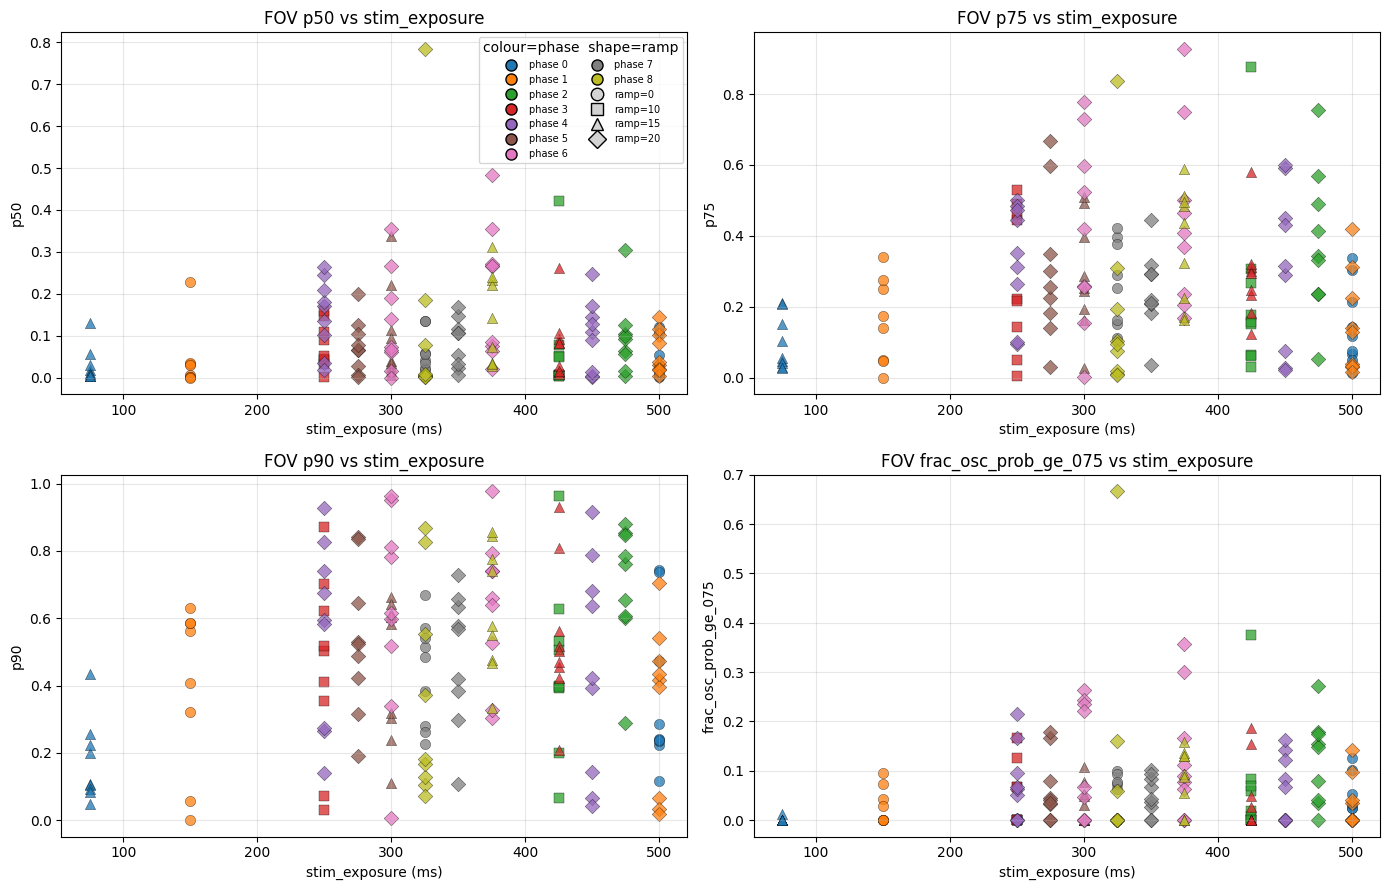

In [10]:
# Color = phase, marker shape = ramp value.
# Each unique ramp gets its own marker; legend shows both.
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
phases_unique = sorted(fov_summary["phase_id"].unique())
ramps_unique = sorted(fov_summary["ramp"].unique())
cmap = plt.cm.tab10
marker_pool = ["o", "s", "^", "D", "v", "P", "X", "*", "<", ">"]
ramp_to_marker = {
    r: marker_pool[i % len(marker_pool)] for i, r in enumerate(ramps_unique)
}

for ax, target in zip(axes.ravel(), ["p50", "p75", "p90", "frac_osc_prob_ge_075"]):
    for pid in phases_unique:
        for ramp_val in ramps_unique:
            sub = fov_summary[
                (fov_summary["phase_id"] == pid) & (fov_summary["ramp"] == ramp_val)
            ]
            if sub.empty:
                continue
            ax.scatter(
                sub["stim_exposure"],
                sub[target],
                c=[cmap(pid % 10)],
                s=55,
                alpha=0.75,
                marker=ramp_to_marker[ramp_val],
                edgecolors="black",
                linewidths=0.3,
            )
    ax.set_xlabel("stim_exposure (ms)")
    ax.set_ylabel(target)
    ax.set_title(f"FOV {target} vs stim_exposure")
    ax.grid(alpha=0.3)

# Composite legend: phase colours + ramp markers, shown once on top-left axes.
from matplotlib.lines import Line2D

phase_handles = [
    Line2D(
        [0],
        [0],
        marker="o",
        color="w",
        markerfacecolor=cmap(p % 10),
        markeredgecolor="black",
        markersize=8,
        label=f"phase {p}",
    )
    for p in phases_unique
]
ramp_handles = [
    Line2D(
        [0],
        [0],
        marker=ramp_to_marker[r],
        color="w",
        markerfacecolor="lightgray",
        markeredgecolor="black",
        markersize=9,
        label=f"ramp={r:g}",
    )
    for r in ramps_unique
]
axes[0, 0].legend(
    handles=phase_handles + ramp_handles,
    fontsize=7,
    ncol=2,
    loc="upper right",
    title="colour=phase  shape=ramp",
)
plt.tight_layout()
plt.show()